In [14]:
# NumPy is used for numerical operations and reproducible random values.
import numpy as np
# Pandas is used to load and manipulate the applicant dataset.
import pandas as pd
# Matplotlib is used to display model evaluation plots.
import matplotlib.pyplot as plt
# Pickle is used to save the trained model pipeline as a .pkl file.
import pickle
# os is used to create folders and construct local Colab file paths.
import os

In [15]:
# Utilities required for splitting data, preprocessing features, training,
# evaluating, and displaying the machine-learning model.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, RocCurveDisplay


In [16]:
# Fix the random seed so that model training and data splitting are reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [26]:
# Define the default Colab runtime path.
# Files stored in /content are available during the current Colab session.
MODEL_DIR = '/content'

# Define the paths for the input dataset, trained model, and holdout test set.
#/content/tn_synthetic_aid_dataset.csv
DATA_PATH = os.path.join(MODEL_DIR, 'tn_synthetic_aid_dataset.csv')
MODEL_PATH = os.path.join(MODEL_DIR, 'yield_model_pipeline.pkl')
HOLDOUT_PATH = os.path.join(MODEL_DIR, 'yield_test_holdout.csv')

In [27]:
# Stop execution with a clear message if Notebook 1 has not generated the dataset yet.
assert os.path.exists(DATA_PATH), (
    f"{DATA_PATH} not found — run Notebook 1 first."
)

# Load the synthetic applicant data from the local Colab CSV file.
df = pd.read_csv(DATA_PATH)
print('Loaded:', df.shape)
df.head()

Loaded: (6000, 18)


,district,category,urban,family_income,first_gen,parent_grad,cutoff_12th,entrance_score,college_tier,tuition,distance_km,competing_offers,merit_aid_pct,need_aid_pct,total_aid_pct,aid_amount,net_price,enrolled
0,Coimbatore,SC,1,691000.0,0,1,92.35,145.6,Tier-2 (Affiliated),110000.0,29.8,3,0.443,0.430,0.437,48000.0,62000.0,1
1,Nagapattinam,MBC,0,686000.0,1,0,77.63,130.7,Tier-3 (Self-financing),91000.0,15.8,0,0.389,0.324,0.357,32500.0,58500.0,1
2,Cuddalore,BC,1,579000.0,0,1,68.22,104.2,Tier-2 (Affiliated),108000.0,66.9,0,0.292,0.422,0.357,38500.0,69500.0,1
3,Thanjavur,SC,0,99000.0,0,0,80.98,129.6,Tier-3 (Self-financing),91000.0,31.2,1,0.504,0.457,0.481,43800.0,47200.0,0
4,Thanjavur,OC,0,1034000.0,1,0,77.28,126.9,Tier-2 (Affiliated),119000.0,19.4,2,0.395,0.389,0.392,46600.0,72400.0,0


In [28]:
# Define the target column that the model will learn to predict.
target = "enrolled"

# Numerical features used by the model.
num_feats = ["urban", "family_income", "first_gen", "parent_grad", "cutoff_12th", "entrance_score",
             "tuition", "distance_km", "competing_offers", "merit_aid_pct", "need_aid_pct",
             "total_aid_pct", "aid_amount", "net_price"]

# Categorical features used by the model.
cat_feats = ["district", "category", "college_tier"]

In [29]:
# Select the input features and target values from the loaded dataset.
X = df[num_feats + cat_feats]
y = df[target]

# Split the data into 80% training data and 20% testing data.
# Stratification keeps the enrolled/non-enrolled class distribution similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, '| Test:', X_test.shape)


Train: (4800, 17) | Test: (1200, 17)


In [30]:
# Preprocess numerical and categorical features separately.
preprocessor = ColumnTransformer([
    # StandardScaler puts numerical features on a comparable scale.
    ("num", StandardScaler(), num_feats),
    # OneHotEncoder converts categorical values into machine-readable binary columns.
    # handle_unknown='ignore' prevents errors when a new category appears during inference.
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
])

# Create one complete pipeline containing preprocessing followed by the classifier.
yield_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        # Use 300 decision trees to build the Random Forest ensemble.
        n_estimators=300,
        # Limit tree depth to reduce unnecessary complexity.
        max_depth=10,
        # Require at least five samples in each leaf for more stable predictions.
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        # Use all available CPU cores for faster training.
        n_jobs=-1
    )),
])

In [31]:
# Train the complete preprocessing + Random Forest pipeline using the training data.
yield_model.fit(X_train, y_train)
print('Trained.')

Trained.


In [36]:
# Generate the probability that each test applicant will enroll.
proba = yield_model.predict_proba(X_test)[:, 1]

# Convert probabilities into binary predictions using a 0.5 decision threshold.
pred = (proba >= 0.5).astype(int)

# Calculate classification accuracy and ROC-AUC to evaluate model performance.
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC:  {auc:.3f}")

# Display precision, recall, and F1-score for both enrollment classes.
print(classification_report(y_test, pred, target_names=['Did not enroll', 'Enrolled']))

Accuracy: 0.653
ROC-AUC:  0.702
                precision    recall  f1-score   support

Did not enroll       0.64      0.47      0.54       525
      Enrolled       0.66      0.80      0.72       675

      accuracy                           0.65      1200
     macro avg       0.65      0.63      0.63      1200
  weighted avg       0.65      0.65      0.64      1200



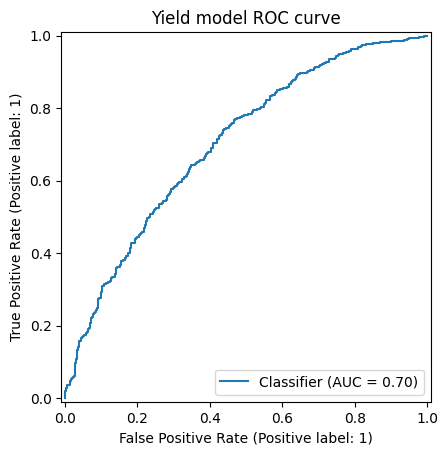

In [37]:
# Plot the ROC curve to visualize the model's ability to distinguish the two classes.
RocCurveDisplay.from_predictions(y_test, proba)
plt.title('Yield model ROC curve')
plt.show()

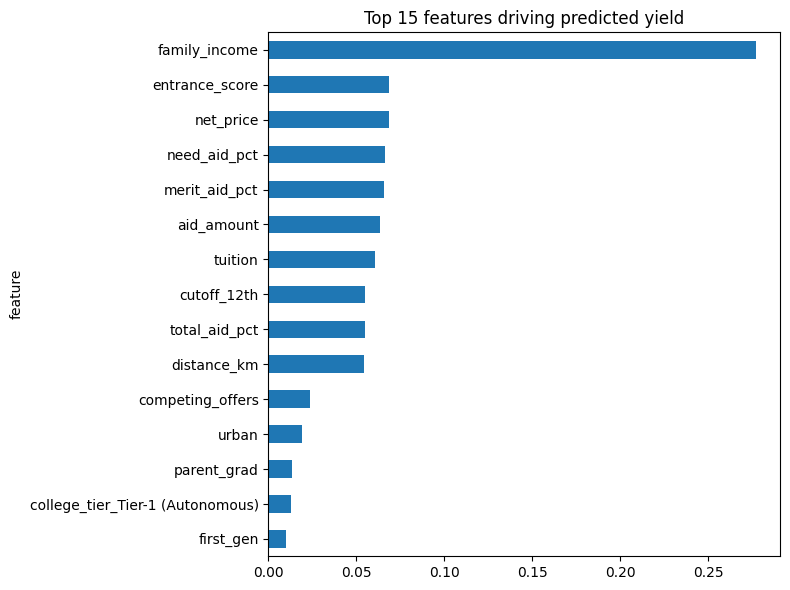

In [38]:
# Extract the fitted one-hot encoder from the trained preprocessing pipeline.
ohe = yield_model.named_steps['preprocessor'].named_transformers_['cat']

# Combine numerical feature names with the generated one-hot categorical feature names.
feature_names = num_feats + list(ohe.get_feature_names_out(cat_feats))

# Retrieve the Random Forest feature-importance values.
importances = yield_model.named_steps['classifier'].feature_importances_

# Create a table and select the 15 features with the largest importance values.
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)

# Plot the top 15 features to show which inputs contributed most to the trained model.
imp_df.plot(kind='barh', x='feature', y='importance', figsize=(8, 6), legend=False, title='Top 15 features driving predicted yield')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [39]:
# Store the trained pipeline and the feature configuration in one dictionary.
bundle = {
    'pipeline': yield_model,
    'num_feats': num_feats,
    'cat_feats': cat_feats,
    'target': target,
    'trained_on': DATA_PATH,
    'metrics': {'accuracy': float(acc), 'roc_auc': float(auc)},
    'notes': 'Pipeline includes preprocessing; feed it raw applicant rows with columns = num_feats + cat_feats.'
}

# Serialize the trained model bundle to a local Colab .pkl file.
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(bundle, f)
print('Model saved ->', MODEL_PATH)

# Save the held-out test data for the testing notebook.
holdout_df = X_test.copy()
holdout_df[target] = y_test.values
holdout_df.to_csv(HOLDOUT_PATH, index=False)
print('Held-out test set saved ->', HOLDOUT_PATH)

Model saved -> /content/yield_model_pipeline.pkl
Held-out test set saved -> /content/yield_test_holdout.csv
